# Titanic Dataset — Exploratory Data Analysis (EDA)

**Goal:** Understand who survived the Titanic disaster and why, by examining data quality, then breaking survival down by sex, passenger class, and age.

**Dataset:** 891 passengers from the classic Kaggle Titanic competition (`train.csv`), which includes the `Survived` label needed for this analysis.

> Note: the `test.csv` you uploaded is Kaggle's unlabeled holdout set (no `Survived` column), so it can't be used to study survival rates. This notebook uses the labeled training data instead — the standard file for this exact analysis. Swap in your own file at any time; the code doesn't change, only the source path.

**Structure:**
1. Load data & inspect structure
2. Check missingness & data types
3. Survival by sex
4. Survival by passenger class
5. Survival by age bucket
6. Combined view (sex × class)
7. Distribution plots (violin/box)
8. Insight report


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Load the dataset and inspect its shape

First look at any dataset: how big is it, what columns exist, and what type is each column stored as.
Getting dtypes wrong (e.g. treating `Pclass` as a number to average, when it's really a category) is one of the most common EDA mistakes.

In [2]:
df = pd.read_csv("titanic_full.csv")
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Reading this:**
- `891 rows`, `12 columns`.
- `Age`, `Cabin`, `Embarked` show fewer non-null entries than 891 — that's our missingness.
- `Pclass` is stored as `int64` but it's really an ordinal category (1st/2nd/3rd class), not a quantity — worth remembering before you average it.

## 2. Inspect missingness

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary


,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


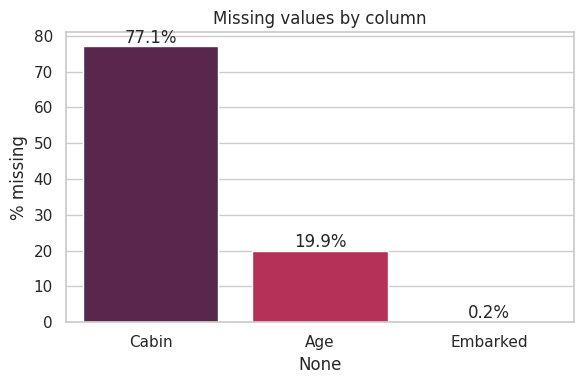

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"], hue=missing_summary.index,
            palette="rocket", legend=False, ax=ax)
ax.set_ylabel("% missing")
ax.set_title("Missing values by column")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.tight_layout()
plt.show()


**Reading this:**
- `Cabin` is missing for ~77% of passengers — too sparse to use directly; at most, engineer a `has_cabin` flag from it.
- `Age` is missing for ~20% (177 of 891) — significant, but recoverable. A common approach is imputing by median `Age` within each `Pclass`/`Sex` group rather than a single global median, since age varies a lot by class.
- `Embarked` is missing for only 2 rows — negligible, safe to drop or fill with the mode.

## 3. Create age buckets

To analyze survival "by age," continuous `Age` needs to be grouped into buckets. Bucket edges are a judgment call — here we use developmentally meaningful cutoffs rather than even-width bins.

In [6]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child (0-12)", "Teen (13-18)", "Adult (19-35)", "Middle Age (36-60)", "Senior (60+)"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["AgeGroup"].value_counts(dropna=False).reindex(labels + [np.nan])


AgeGroup
Child (0-12)           69
Teen (13-18)           70
Adult (19-35)         358
Middle Age (36-60)    195
Senior (60+)           22
NaN                   177
Name: count, dtype: int64

Rows with missing `Age` become `NaN` in `AgeGroup` — they're excluded from the age-bucket analysis below rather than silently guessed at.

## 4. Survival rate by sex

In [7]:
overall_rate = df["Survived"].mean()
by_sex = df.groupby("Sex")["Survived"].agg(["mean", "count"]).rename(columns={"mean": "survival_rate"})
print(f"Overall survival rate: {overall_rate:.1%}")
by_sex


Overall survival rate: 38.4%


,survival_rate,count
Sex,,
female,0.742038,314
male,0.188908,577


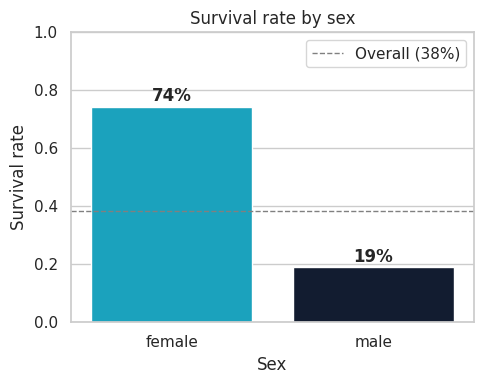

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=by_sex.index, y=by_sex["survival_rate"], hue=by_sex.index,
            palette={"female": "#00B4D8", "male": "#0D1B35"}, legend=False, ax=ax)
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1, label=f"Overall ({overall_rate:.0%})")
ax.set_ylim(0, 1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by sex")
for i, v in enumerate(by_sex["survival_rate"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Survival rate by passenger class

In [9]:
by_class = df.groupby("Pclass")["Survived"].agg(["mean", "count"]).rename(columns={"mean": "survival_rate"})
by_class


,survival_rate,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


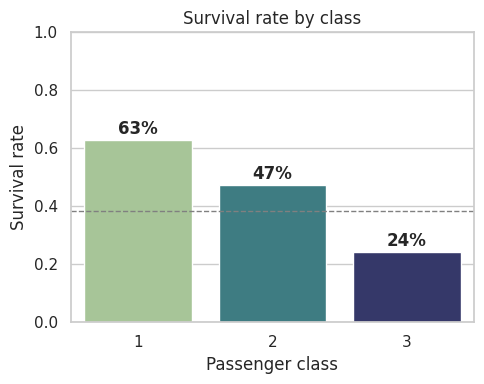

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=by_class.index, y=by_class["survival_rate"], hue=by_class.index,
            palette="crest", legend=False, ax=ax)
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by class")
for i, v in enumerate(by_class["survival_rate"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Survival rate by age bucket

In [11]:
by_age = df.groupby("AgeGroup", observed=True)["Survived"].agg(["mean", "count"]).rename(columns={"mean": "survival_rate"})
by_age


,survival_rate,count
AgeGroup,,
Child (0-12),0.579710,69
Teen (13-18),0.428571,70
Adult (19-35),0.382682,358
Middle Age (36-60),0.400000,195
Senior (60+),0.227273,22


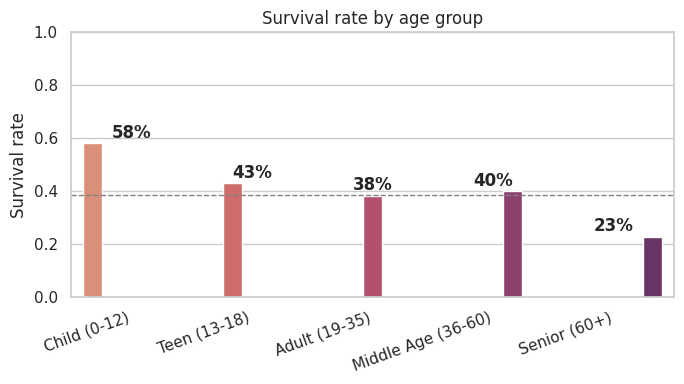

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=by_age.index, y=by_age["survival_rate"], hue=by_age.index,
            palette="flare", legend=False, ax=ax)
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by age group")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(by_age["survival_rate"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Combined view: sex × class

Single-factor breakdowns can hide interactions. Splitting by sex *and* class at once shows whether the class effect holds within each sex — it doesn't hold equally.

In [13]:
combo = df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()
combo


Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


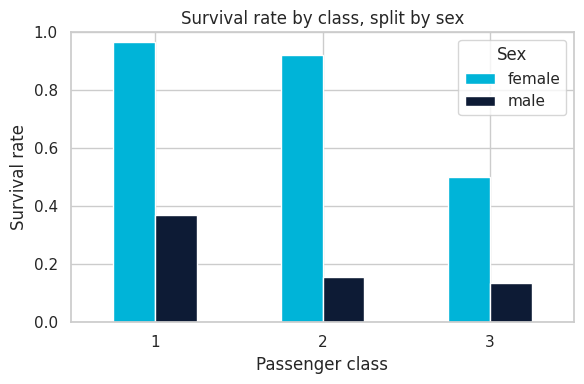

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
combo.T.plot(kind="bar", ax=ax, color=["#00B4D8", "#0D1B35"])
ax.set_ylim(0, 1)
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by class, split by sex")
ax.legend(title="Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Distribution plots: Age and Fare by survival

Bar charts of rates hide the underlying distributions. Violin/box plots show the full spread of `Age` and `Fare` for those who survived vs. didn't — including outliers and skew that a single average would mask.

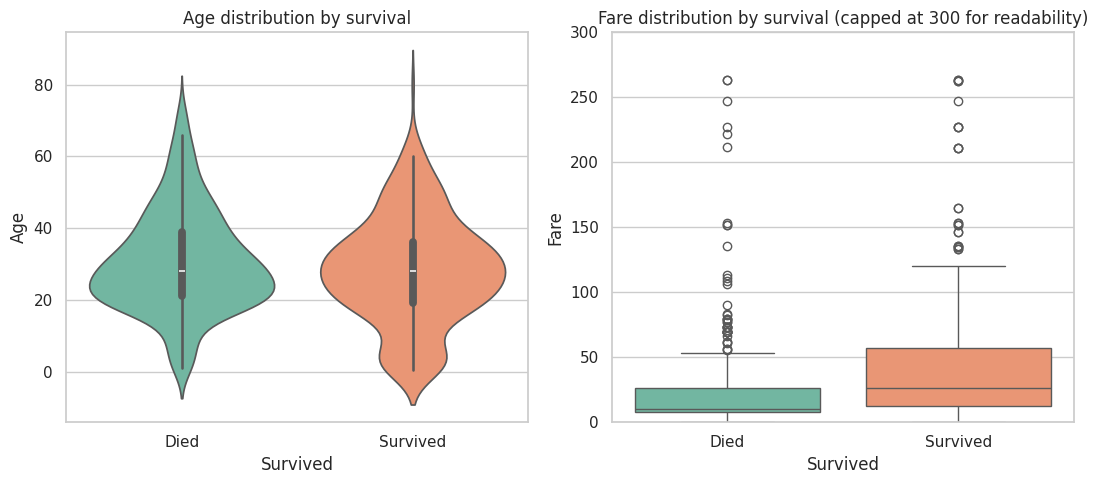

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.violinplot(data=df, x="Survived", y="Age", hue="Survived", palette="Set2", legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Died", "Survived"])
axes[0].set_title("Age distribution by survival")

sns.boxplot(data=df, x="Survived", y="Fare", hue="Survived", palette="Set2", legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Died", "Survived"])
axes[1].set_ylim(0, 300)  # a few extreme fares (500+) would otherwise squash the plot
axes[1].set_title("Fare distribution by survival (capped at 300 for readability)")

plt.tight_layout()
plt.show()


Fare distribution by class, as a second cut on the same idea — richer tickets cluster in the classes that also survived more:

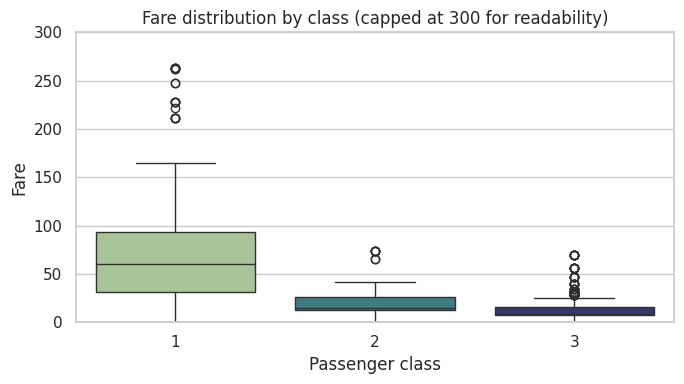

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Pclass", palette="crest", legend=False, ax=ax)
ax.set_ylim(0, 300)
ax.set_xlabel("Passenger class")
ax.set_title("Fare distribution by class (capped at 300 for readability)")
plt.tight_layout()
plt.show()


## 9. Insight report

- **Sex was the single strongest predictor of survival.** Women survived at **74%** vs. **19%** for men — a ~55-point gap, far larger than any other factor examined ("women and children first" shows up directly in the data).
- **Class tracked survival almost linearly**: 1st class **63%**, 2nd class **47%**, 3rd class **24%** — a 39-point gap between top and bottom class, consistent with 1st class cabins sitting closer to lifeboat deck and higher fares buying priority.
- **Sex and class compounded rather than substituted for each other.** 1st-class women survived at **97%** and 2nd-class women at **92%**, while 3rd-class men survived at only **14%** — the two factors stack, they don't cancel out.
- **Children had a real but partial survival edge.** Under-12s survived at **58%**, above the 38% overall average, but well below the rate for adult women — the "children first" effect was real but smaller than the "women first" effect, and seniors (60+) fared worst of all age groups at **23%**.
- **~20% of `Age` values and ~77% of `Cabin` values are missing**, so any age-based conclusion implicitly excludes 177 passengers, and `Cabin` isn't usable directly without imputation or being reduced to a simpler "had a recorded cabin" flag.
